In [1]:
import os
import torch
import pandas as pd
import torch
import xarray as xr
import numpy as np
from skimage import io, transform
import random
import matplotlib.pyplot as plt
from torchvision import transforms, utils
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import functions_NN_extremes
import torch.nn as nn                   # provides classes and functions to create and train neural networks
import torch.nn.functional as F         # provides functions for activation functions, loss functions, and other operations
import functions_NN_extremes
from sklearn.metrics import confusion_matrix
import seaborn as sns
import re 
import shap 
from sklearn.metrics import balanced_accuracy_score
import pickle
import functions_improve_CombinedModel
import convnext_functions
import modified_convnext_functions
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors


### Counts HW per year 

Doing site: cordoba


ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


Mean counts 1950-2000 for cordoba is : 5.354166666666667
Doing site: lyon
Mean counts 1950-2000 for lyon is : 7.229166666666667
Doing site: hannover
Mean counts 1950-2000 for hannover is : 3.4166666666666665
Doing site: stockholm
Mean counts 1950-2000 for stockholm is : 4.239130434782608
Doing site: belgrado
Mean counts 1950-2000 for belgrado is : 4.520833333333333
Doing site: marrakech
Mean counts 1950-2000 for marrakech is : 4.0625


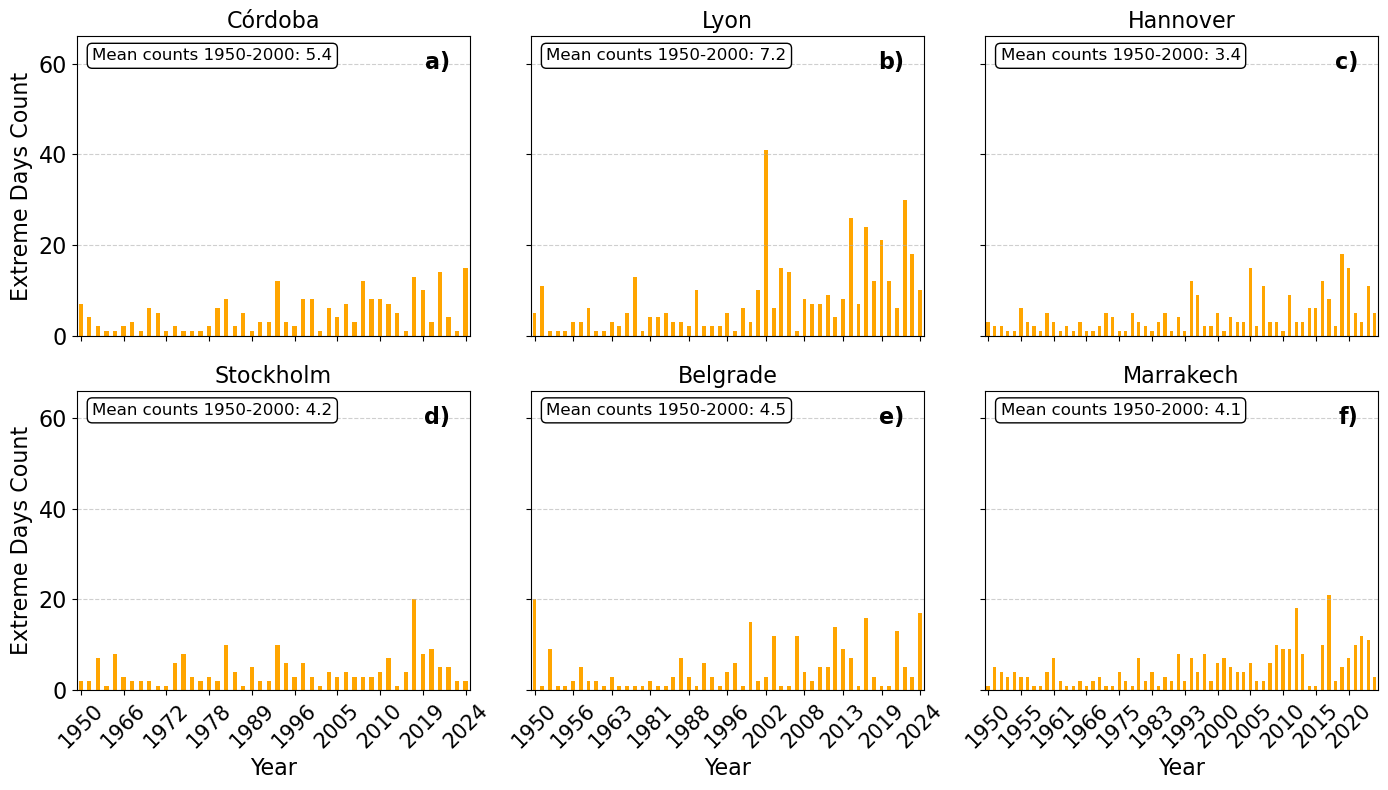

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import matplotlib.ticker as ticker

sites = ['cordoba', 'lyon', 'hannover', 'stockholm', 'belgrado', 'marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

# Create subplots with shared axes
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
axes = axes.flatten()

date_range = pd.date_range(start='1950-01-01', end='2024-12-31', freq='D')
filtered_dates = np.array([
    d for d in date_range 
    if d.month in [6, 7, 8] and not (d.year == 2024 and d.month == 7 and d.day == 31)
])


for i, site in enumerate(sites): 
    print(f"Doing site: {site}")

    dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/98p_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", start_date="1950-01-03", end_date="2024-12-31", months=[6,7,8])
    
    
    y_true = dataset.labels
    
    df = pd.DataFrame({
        'date': filtered_dates,
        'label': y_true
    })
    df['year'] = pd.DatetimeIndex(df['date']).year
    counts = df[df['label'] == 1].groupby('year').size()
    counts = counts.groupby(counts.index).sum()  
    counts = counts.sort_index()
    counts.index = counts.index.astype(int)
    mean_counts = np.mean(counts[:48])
    print(f"Mean counts 1950-2000 for {site} is : {mean_counts}")
    
    ax = axes[i]
    ax.clear()
    counts.plot(kind='bar', ax=ax, color='orange')
    ax.set_title(sites_title[i],fontsize=16)
    ax.set_xlabel('Year', fontsize=16)

    ax.text(0.95, 0.95, f'{chr(97+i)})',  # 97 is ASCII for 'a'
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='right')
    
    # Only set ylabel for leftmost plots
    if i % 3 == 0:
        ax.set_ylabel('Extreme Days Count', fontsize=16)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))  # every 5 years
    ax.tick_params(axis='x', labelsize=15)
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
    
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    ax.text(0.04, 0.96,
               f"Mean counts 1950-2000: {mean_counts:.1f}",
               transform=ax.transAxes,
               fontsize=12,
               verticalalignment='top',
               bbox=dict(boxstyle="round", facecolor="white"))

    ax.set_ylim(0,66)

#plt.suptitle("Yearly Extreme Count of the different Locations",fontsize=15)
plt.tight_layout()
plt.savefig("/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/98p_yearly_counts_extremes_locations.pdf")
plt.show()

In [8]:
print(y_true.shape)
print(filtered_dates.shape)

(6899,)
(6808,)


## Count per year comparison

Doing site: cordoba
Doing site: lyon
Doing site: hannover
Doing site: stockholm
Doing site: belgrado
Doing site: marrakech


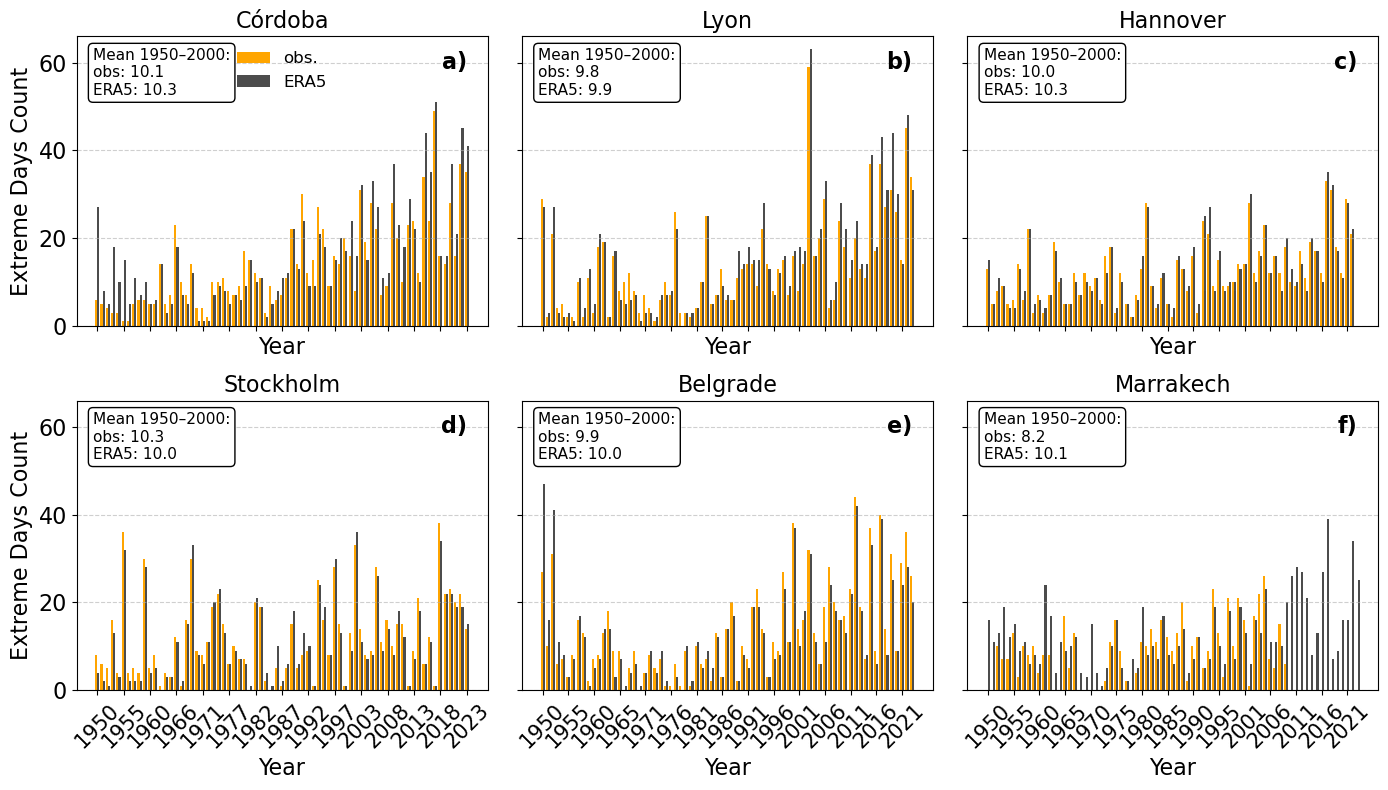

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import matplotlib.ticker as ticker

sites = ['cordoba', 'lyon', 'hannover', 'stockholm', 'belgrado', 'marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

# Create subplots with shared axes
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
axes = axes.flatten()

date_range = pd.date_range(start='1950-01-01', end='2023-12-31', freq='D')
filtered_dates = np.array([
    d for d in date_range 
    if d.month in [6, 7, 8] and not (d.year == 2024 and d.month == 7 and d.day == 31)
])


bar_width = 0.4

for i, site in enumerate(sites): 
    print(f"Doing site: {site}")

    # First dataset (original)
    dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(
        file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/obs_lagged_anomalies_and_event_detection/obs_{site}_lagged_standarized_anomalies_and_extreme_detection.nc",
        start_date="1950-01-03", end_date="2023-12-31", months=[6,7,8])
    
    y_true = dataset.labels
    df = pd.DataFrame({'date': filtered_dates, 'label': y_true})
    df['year'] = df['date'].dt.year
    counts_obs = df[df['label'] == 1].groupby('year').size()

    # Second dataset (altered std)
    dataset_alt = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(
        file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/std_changed_{site}_lagged_standarized_anomalies_and_extreme_detection.nc",
        start_date="1950-01-03", end_date="2023-12-31", months=[6,7,8])
    
    y_true_alt = dataset_alt.labels
    df_alt = pd.DataFrame({'date': filtered_dates, 'label': y_true_alt})
    df_alt['year'] = df_alt['date'].dt.year
    counts_alt = df_alt[df_alt['label'] == 1].groupby('year').size()

    # Align both datasets to the same set of years
    all_years = sorted(set(counts_obs.index).union(set(counts_alt.index)))
    counts_obs = counts_obs.reindex(all_years, fill_value=0)
    counts_alt = counts_alt.reindex(all_years, fill_value=0)

    mean_counts_obs = np.mean(counts_obs.loc[1950:2000])
    mean_counts_alt = np.mean(counts_alt.loc[1950:2000])

    # Plot
    ax = axes[i]
    ax.clear()

    x = np.arange(len(all_years))
    ax.bar(x - bar_width/2, counts_obs.values, width=bar_width, color='orange', label='obs.')
    ax.bar(x + bar_width/2, counts_alt.values, width=bar_width, color='black', alpha=0.7, label='ERA5')

    ax.set_title(sites_title[i], fontsize=16)
    ax.set_xlabel('Year', fontsize=16)
    ax.set_xticks(x[::5])
    ax.set_xticklabels([str(year) for year in all_years][::5], rotation=45, fontsize=15)

    if i % 3 == 0:
        ax.set_ylabel('Extreme Days Count', fontsize=16)
    
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_ylim(0, 66)

    ax.text(0.95, 0.95, f'{chr(97+i)})',
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='right')
    
    ax.text(0.04, 0.96,
            f"Mean 1950–2000:\nobs: {mean_counts_obs:.1f}\nERA5: {mean_counts_alt:.1f}",
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white"))

# Add legend to the first subplot
axes[0].legend(fontsize=12, loc='upper center',frameon=False)

plt.tight_layout()
#plt.savefig("/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/obs_TX_yearly_counts_extremes_locations_groupedbars.pdf")
plt.show()

# Mean Absolute SHAP values

doing site: cordoba
Finished site cordoba
doing site: lyon
Finished site lyon
doing site: hannover
Finished site hannover
doing site: stockholm
Finished site stockholm
doing site: belgrado
Finished site belgrado
doing site: marrakech
Finished site marrakech


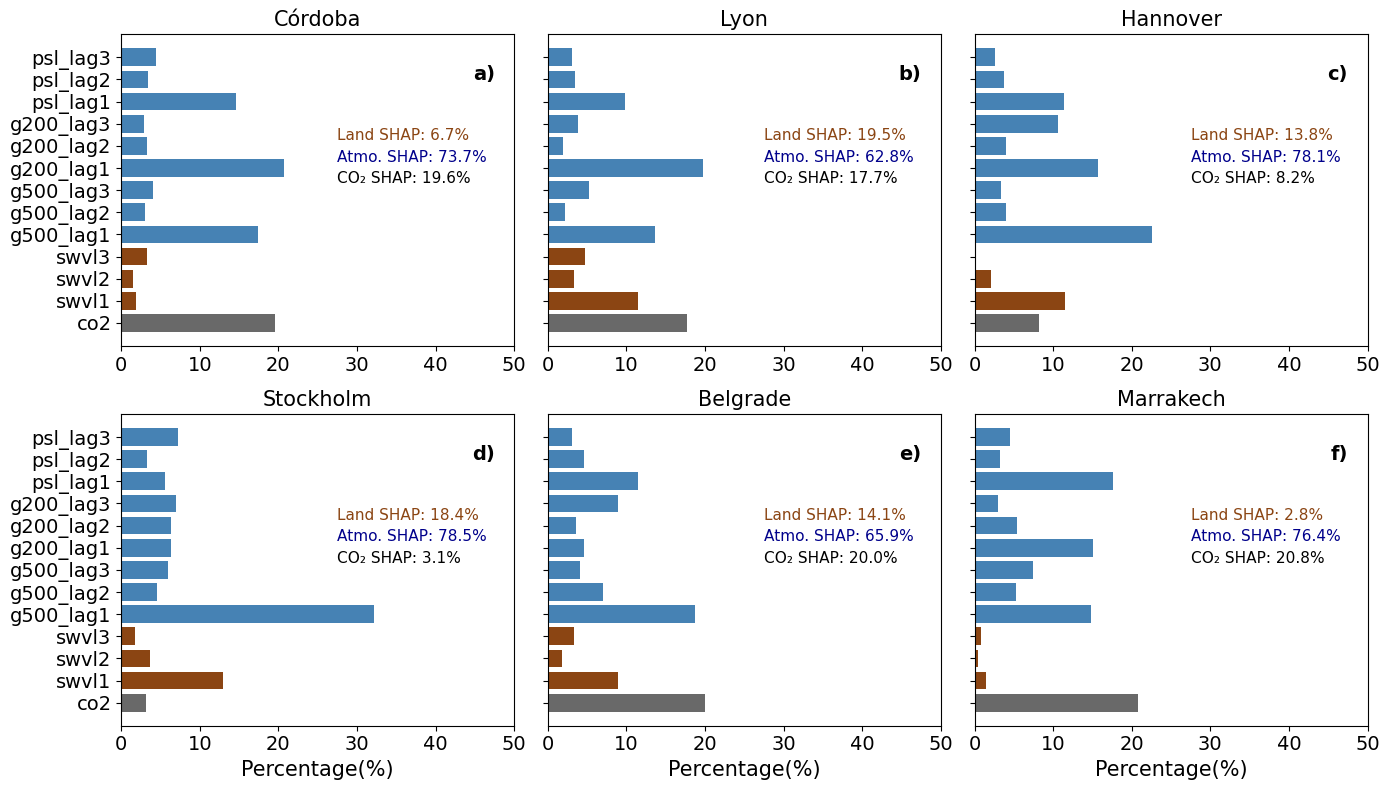

In [10]:
def draw_colored_text_block(ax, x, y, items):
    for i, (name, value, color) in enumerate(items):
        ax.text(x, y - i*0.07, f"{name}: {value:.1f}%", transform=ax.transAxes,
                fontsize=11, color=color, verticalalignment='top')


atmo_color = 'steelblue' 
land_color = 'saddlebrown'    
co2_color = 'dimgray'    

sites = ['cordoba','lyon','hannover' ,'stockholm','belgrado','marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade' ,'Marrakech']



# -----------------------------------------

_DATALOADERS_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = True,
    )
    
_DATALOADERS_TEST_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = False,
    ) 
    
HYPMS = dict(
    epochs= 75,
    lr= 1e-4,
    w_decay= 0.01,
)


#File paths ERA5 data 

file_g500 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/std_changed_g500_1x1_lagged_standarized_anomalies.nc"
file_g200 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/std_changed_g200_1x1_lagged_standarized_anomalies.nc"
file_psl = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/std_changed_psl_1x1_lagged_standarized_anomalies.nc"
file_hus850 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/hus850_lagged_standarized_anomalies.nc"
file_hus975 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/hus975_lagged_standarized_anomalies.nc"
file_rsds = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/rsds_lagged_standarized_anomalies.nc"
file_hus700 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/hus700_lagged_standarized_anomalies.nc"

file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"


# Train features 

number_lags = 3


# Combined Dataset and Dataloader 

batch_size = _DATALOADERS_CONF['batch_size'] # batch size for dataloaders both datasets

fig_bar,axes_bar = plt.subplots(2,3,figsize=(14,8), sharex='col', sharey='row')
axes_bar = axes_bar.flatten()

count_plot = 0

for s,site in enumerate(sites): 

    print(f"doing site: {site}")
    
    if site == 'belgrado': # Special case Belgrado to capture correctly the trend, discarding special case 1950 and 1952, which have a high extreme count. 
            start_date = "1953-01-01"
    else:
        start_date = "1950-01-01"
    
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"
    _ERA5LAND_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2024-12-31",
    months = [6,7,8]         
        )

    _ERA5_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2024-12-31",
    start_lag = 1,
    lags_era5 = 3,
    months = [6,7,8],
            )

    train_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/std_changed_{site}_lagged_standarized_anomalies_and_95p_extreme_detection.nc", file_CO2=file_CO2 ,start_date=start_date, end_date="2013-12-31", months=[6,7,8])
    test_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/std_changed_{site}_lagged_standarized_anomalies_and_95p_extreme_detection.nc", file_CO2=file_CO2 ,start_date="2014-01-01", end_date="2023-12-31", months=[6,7,8])
        

    train_features_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, start_date=start_date, end_date='2013-12-31',months=[6,7,8],start_lag=1,lags_era5=number_lags) # shape: features, time, lat, lon 
    test_features_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, start_date='2014-01-01', end_date='2023-12-31', months=[6,7,8],start_lag=1,lags_era5=number_lags)


    combined_train_dataset  = functions_NN_extremes.CombinedDataset(train_dataset,train_features_era5)
    combined_test_dataset = functions_NN_extremes.CombinedDataset(test_dataset,test_features_era5)
          
    #complete_era5land = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , **_ERA5LAND_COMPLETE_DATASET_CONF)
    #complete_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_COMPLETE_DATASET_CONF)
    #complete_combined_dataset = functions_NN_extremes.CombinedDataset(complete_era5land,complete_era5)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Explainer data for SHAP 
    
    explainer_indices = np.arange(0,len(combined_test_dataset),1)
    
    explain_nn = []
    explain_cnn = []
    
    for idx in explainer_indices:
        nn_input, cnn_input, labels = combined_test_dataset[idx]  # Adjust based on your dataset structure
        explain_nn.append(nn_input)
        explain_cnn.append(cnn_input)
    
    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    explain_cnn = torch.stack(explain_cnn,dim=0).to(device)
    
    explain_data = [explain_nn, explain_cnn]
    
    
    # Load computed SHAP


    main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
    with open(os.path.join(main_path, f'95p_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)

    main_path = '/gpfs/projects/bsc32/bsc167965/SHAP_values_Gradient/def_ensamble/'
    with open(os.path.join(main_path, f'95p_SHAP_results_{site}.pkl'), 'rb') as f:
        loaded_shap_dict = pickle.load(f)
    
   #with open(f'SHAP_values_Gradient/def_ensamble/SHAP_values_GradientExplainer_not_filtered_{site}_{number_lags}lags.pkl', 'rb') as f:
   #    loaded_shap_dict = pickle.load(f)
#
   #main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
   #with open(os.path.join(main_path, f'results_data_{site}.pkl'), 'rb') as f:
   #    dict_results = pickle.load(f)
    

    out_probabilities = dict_results['out_probs_sites']   

    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
        
    # Filter the predictions based on probabilities 
        
        
    mask = np.zeros_like(out_probabilities, dtype=bool)
    
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 100 - 25)
    
        mask[:, i] = out_probabilities[:, i] >= threshold
    
    mask_def = mask[:,0] | mask[:,1] #True if either class 0 or 1 correspond to the top % confidence 

    mask_def_extreme = mask_def & (y_pred == 1)

    # Load SHAP values 

    shap_values_nn_raw = loaded_shap_dict['nn_mean']
    shap_values_cnn_raw = loaded_shap_dict['cnn_mean']

    # Filter shap values with mask 

    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    shap_values_cnn_filtered = shap_values_cnn_raw[mask_def_extreme]

    # Get names features and Explanation for the SHAP plot 

    explain_nn_np = explain_nn.cpu().numpy()
    explain_nn_np
    
    nn_feature_names = test_dataset.all_features
    cnn_feature_names = test_features_era5.all_features
    all_names = nn_feature_names + cnn_feature_names
    
    cleaned_names = [
    name.replace("_anomalies", "").replace("lagged_era5", "")
    if "lagged_era5" in name else name.replace("_anomalies", "")
    for name in all_names
    ]

    # Assign colors per feature group
    color_mapping = {}
    circulation_features = ['g500', 'g200', 'psl']
    land_features = ['swvl1', 'swvl2', 'swvl3']
    co2_feature = ['co2']  # assuming the CO2 feature is named "co2"
    
    for name in cleaned_names:
        lname = name.lower()
        if any(circ in lname for circ in circulation_features):
            color_mapping[name] = atmo_color
        elif any(swvl in lname for swvl in land_features):
            color_mapping[name] = land_color
        elif 'co2' in lname:
            color_mapping[name] = co2_color

    
    # Convert to shap.Explanation object
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered,
        data=explain_nn.cpu().numpy()[mask_def_extreme],  # or .detach().cpu().numpy() if needed
        feature_names=nn_feature_names
    )

    shap_values_cnn_sum_spatial = np.sum(shap_values_cnn_filtered,axis=(2,3))

    all_shap_values = np.concatenate([shap_values_nn_filtered,shap_values_cnn_sum_spatial],axis=1)

    abs_shap = np.abs(all_shap_values)
    
    mean_abs_shap = np.mean(np.abs(all_shap_values), axis=0)

    total_mean_shap = np.sum(mean_abs_shap[:],axis=0)

    land_SHAP = np.sum(mean_abs_shap[1:4]) / total_mean_shap * 100
    atmosphere_SHAP = np.sum(mean_abs_shap[4:]) / total_mean_shap * 100
    co2_SHAP = np.sum(mean_abs_shap[:1]) / total_mean_shap * 100

    
    axes_bar[count_plot].set_xticks(np.arange(0, 55, 10))
    bar_colors = [color_mapping[name] for name in cleaned_names]
    axes_bar[count_plot].barh(cleaned_names, mean_abs_shap / total_mean_shap * 100, color=bar_colors)   
    axes_bar[count_plot].set_xlim(0,50)
    axes_bar[count_plot].set_title(f"{sites_title[s]}",fontsize=15)
    axes_bar[count_plot].text(0.95, 0.9, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=axes_bar[count_plot].transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')
    summary_items = [
        ("Land SHAP", land_SHAP, 'saddlebrown'),
        ("Atmo. SHAP", atmosphere_SHAP, 'darkblue'),
        ("CO₂ SHAP", co2_SHAP, 'black')
    ]

    draw_colored_text_block(axes_bar[count_plot], 0.55, 0.70, summary_items)

    axes_bar[count_plot].tick_params(axis='y', labelsize=14) 
    axes_bar[count_plot].tick_params(axis='x', labelsize=14) 
    axes_bar[count_plot].xaxis.set_ticks_position('bottom')



    count_plot += 1
    print(f"Finished site {site}")



for m in range(3,6):
    axes_bar[m].set_xlabel("Percentage(%)",fontsize=15)

#fig_bar.suptitle("Contribution of Mean |SHAP value| CombinedModel (20 members)",fontsize=15)
fig_bar.tight_layout()
#fig_bar.savefig(f"/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/SHAP_values_Gradient/belgrado_std_changed_SHAP_plot_CO2_all_locations_{number_lags}lags.pdf")

    

## Bar plot full period

doing site: cordoba
Finished site cordoba
doing site: lyon
Finished site lyon
doing site: hannover
Finished site hannover
doing site: stockholm
Finished site stockholm
doing site: belgrado
Finished site belgrado
doing site: marrakech
Finished site marrakech


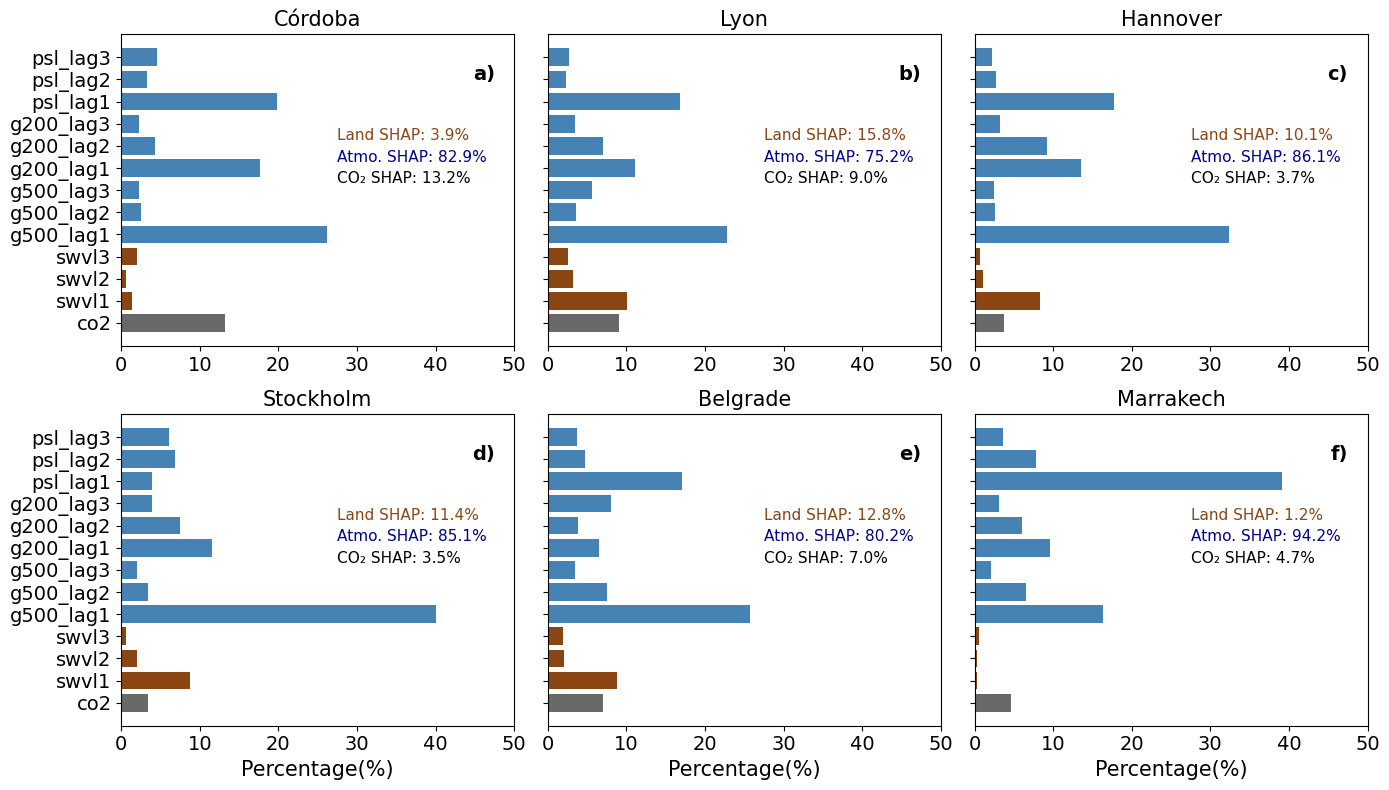

In [6]:
def draw_colored_text_block(ax, x, y, items):
    for i, (name, value, color) in enumerate(items):
        ax.text(x, y - i*0.07, f"{name}: {value:.1f}%", transform=ax.transAxes,
                fontsize=11, color=color, verticalalignment='top')


atmo_color = 'steelblue' 
land_color = 'saddlebrown'    
co2_color = 'dimgray'    

sites = ['cordoba','lyon','hannover' ,'stockholm','belgrado','marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade' ,'Marrakech']


#sites = ['lyon','hannover','stockholm','belgrado','marrakech']


# -----------------------------------------

_DATALOADERS_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = True,
    )
    
_DATALOADERS_TEST_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = False,
    ) 
    
HYPMS = dict(
    epochs= 75,
    lr= 1e-4,
    w_decay= 0.01,
)


#File paths ERA5 data 

file_g500 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/std_changed_g500_1x1_lagged_standarized_anomalies.nc"
file_g200 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/std_changed_g200_1x1_lagged_standarized_anomalies.nc"
file_psl = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/std_changed_psl_1x1_lagged_standarized_anomalies.nc"
file_hus850 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/hus850_lagged_standarized_anomalies.nc"
file_hus975 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/hus975_lagged_standarized_anomalies.nc"
file_rsds = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/rsds_lagged_standarized_anomalies.nc"
file_hus700 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/hus700_lagged_standarized_anomalies.nc"

file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"


# Train features 

number_lags = 3


# Combined Dataset and Dataloader 

batch_size = _DATALOADERS_CONF['batch_size'] # batch size for dataloaders both datasets

fig_bar,axes_bar = plt.subplots(2,3,figsize=(14,8), sharex='col', sharey='row')
axes_bar = axes_bar.flatten()

count_plot = 0

for s,site in enumerate(sites): 

    print(f"doing site: {site}")
    
    if site == 'belgrado': # Special case Belgrado to capture correctly the trend, discarding special case 1950 and 1952, which have a high extreme count. 
            start_date = "1953-01-01"
    else:
        start_date = "1950-01-01"
    
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"
    _ERA5LAND_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2024-12-31",
    months = [6,7,8]         
        )

    _ERA5_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2024-12-31",
    start_lag = 1,
    lags_era5 = 3,
    months = [6,7,8],
            )

    complete_era5land = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/std_changed_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , **_ERA5LAND_COMPLETE_DATASET_CONF)
    complete_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_COMPLETE_DATASET_CONF)
    complete_combined_dataset = functions_NN_extremes.CombinedDataset(complete_era5land,complete_era5)
          
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Explainer data for SHAP 
    
    explainer_indices = np.arange(0,len(complete_combined_dataset),1)
    
    explain_nn = []
    explain_cnn = []
    
    for idx in explainer_indices:
        nn_input, cnn_input, labels = complete_combined_dataset[idx]  # Adjust based on your dataset structure
        explain_nn.append(nn_input)
        explain_cnn.append(cnn_input)
    
    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    explain_cnn = torch.stack(explain_cnn,dim=0).to(device)
    
    explain_data = [explain_nn, explain_cnn]
    
    
    # Load computed SHAP


    main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
    with open(os.path.join(main_path, f'FullPeriod_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)

    main_path = '/gpfs/projects/bsc32/bsc167965/SHAP_values_Gradient/def_ensamble/'
    with open(os.path.join(main_path, f'FullPeriod_SHAP_results_{site}.pkl'), 'rb') as f:
        loaded_shap_dict = pickle.load(f)
    
   #with open(f'SHAP_values_Gradient/def_ensamble/SHAP_values_GradientExplainer_not_filtered_{site}_{number_lags}lags.pkl', 'rb') as f:
   #    loaded_shap_dict = pickle.load(f)
#
   #main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
   #with open(os.path.join(main_path, f'results_data_{site}.pkl'), 'rb') as f:
   #    dict_results = pickle.load(f)
    

    out_probabilities = dict_results['out_probs_sites']   

    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
        
    # Filter the predictions based on probabilities 
        
        
    mask = np.zeros_like(out_probabilities, dtype=bool)
    
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 100 - 100)
    
        mask[:, i] = out_probabilities[:, i] >= threshold
    
    mask_def = mask[:,0] | mask[:,1] #True if either class 0 or 1 correspond to the top % confidence 

    mask_def_extreme = mask_def & (y_pred == 1)

    # Load SHAP values 

    shap_values_nn_raw = loaded_shap_dict['nn_mean']
    shap_values_cnn_raw = loaded_shap_dict['cnn_mean']

    # Filter shap values with mask 

    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    shap_values_cnn_filtered = shap_values_cnn_raw[mask_def_extreme]

    # Get names features and Explanation for the SHAP plot 

    explain_nn_np = explain_nn.cpu().numpy()
    explain_nn_np
    
    nn_feature_names = complete_era5land.all_features
    cnn_feature_names = complete_era5.all_features
    all_names = nn_feature_names + cnn_feature_names
    
    cleaned_names = [
    name.replace("_anomalies", "").replace("lagged_era5", "")
    if "lagged_era5" in name else name.replace("_anomalies", "")
    for name in all_names
    ]

    # Assign colors per feature group
    color_mapping = {}
    circulation_features = ['g500', 'g200', 'psl']
    land_features = ['swvl1', 'swvl2', 'swvl3']
    co2_feature = ['co2']  # assuming the CO2 feature is named "co2"
    
    for name in cleaned_names:
        lname = name.lower()
        if any(circ in lname for circ in circulation_features):
            color_mapping[name] = atmo_color
        elif any(swvl in lname for swvl in land_features):
            color_mapping[name] = land_color
        elif 'co2' in lname:
            color_mapping[name] = co2_color

    
    # Convert to shap.Explanation object
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered,
        data=explain_nn.cpu().numpy()[mask_def_extreme],  # or .detach().cpu().numpy() if needed
        feature_names=nn_feature_names
    )

    shap_values_cnn_sum_spatial = np.sum(shap_values_cnn_filtered,axis=(2,3))

    all_shap_values = np.concatenate([shap_values_nn_filtered,shap_values_cnn_sum_spatial],axis=1)

    abs_shap = np.abs(all_shap_values)
    
    mean_abs_shap = np.mean(np.abs(all_shap_values), axis=0)

    total_mean_shap = np.sum(mean_abs_shap[:],axis=0)

    land_SHAP = np.sum(mean_abs_shap[1:4]) / total_mean_shap * 100
    atmosphere_SHAP = np.sum(mean_abs_shap[4:]) / total_mean_shap * 100
    co2_SHAP = np.sum(mean_abs_shap[:1]) / total_mean_shap * 100

    
    axes_bar[count_plot].set_xticks(np.arange(0, 55, 10))
    bar_colors = [color_mapping[name] for name in cleaned_names]
    axes_bar[count_plot].barh(cleaned_names, mean_abs_shap / total_mean_shap * 100, color=bar_colors)   
    axes_bar[count_plot].set_xlim(0,50)
    axes_bar[count_plot].set_title(f"{sites_title[s]}",fontsize=15)
    axes_bar[count_plot].text(0.95, 0.9, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=axes_bar[count_plot].transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')
    summary_items = [
        ("Land SHAP", land_SHAP, 'saddlebrown'),
        ("Atmo. SHAP", atmosphere_SHAP, 'darkblue'),
        ("CO₂ SHAP", co2_SHAP, 'black')
    ]
    draw_colored_text_block(axes_bar[count_plot], 0.55, 0.70, summary_items)

    axes_bar[count_plot].tick_params(axis='y', labelsize=14) 
    axes_bar[count_plot].tick_params(axis='x', labelsize=14) 
    axes_bar[count_plot].xaxis.set_ticks_position('bottom')



    count_plot += 1
    print(f"Finished site {site}")



for m in range(3,6):
    axes_bar[m].set_xlabel("Percentage(%)",fontsize=15)

#fig_bar.suptitle("Contribution of Mean |SHAP value| CombinedModel (20 members)",fontsize=15)
fig_bar.tight_layout()
fig_bar.savefig(f"/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/SHAP_values_Gradient/FullPeriod_SHAP_plot_CO2_all_locations_{number_lags}lags.pdf")

    

## Difference between lags

Processing site: cordoba
Processing site: lyon
Processing site: hannover
Processing site: stockholm
Processing site: belgrado
Processing site: marrakech


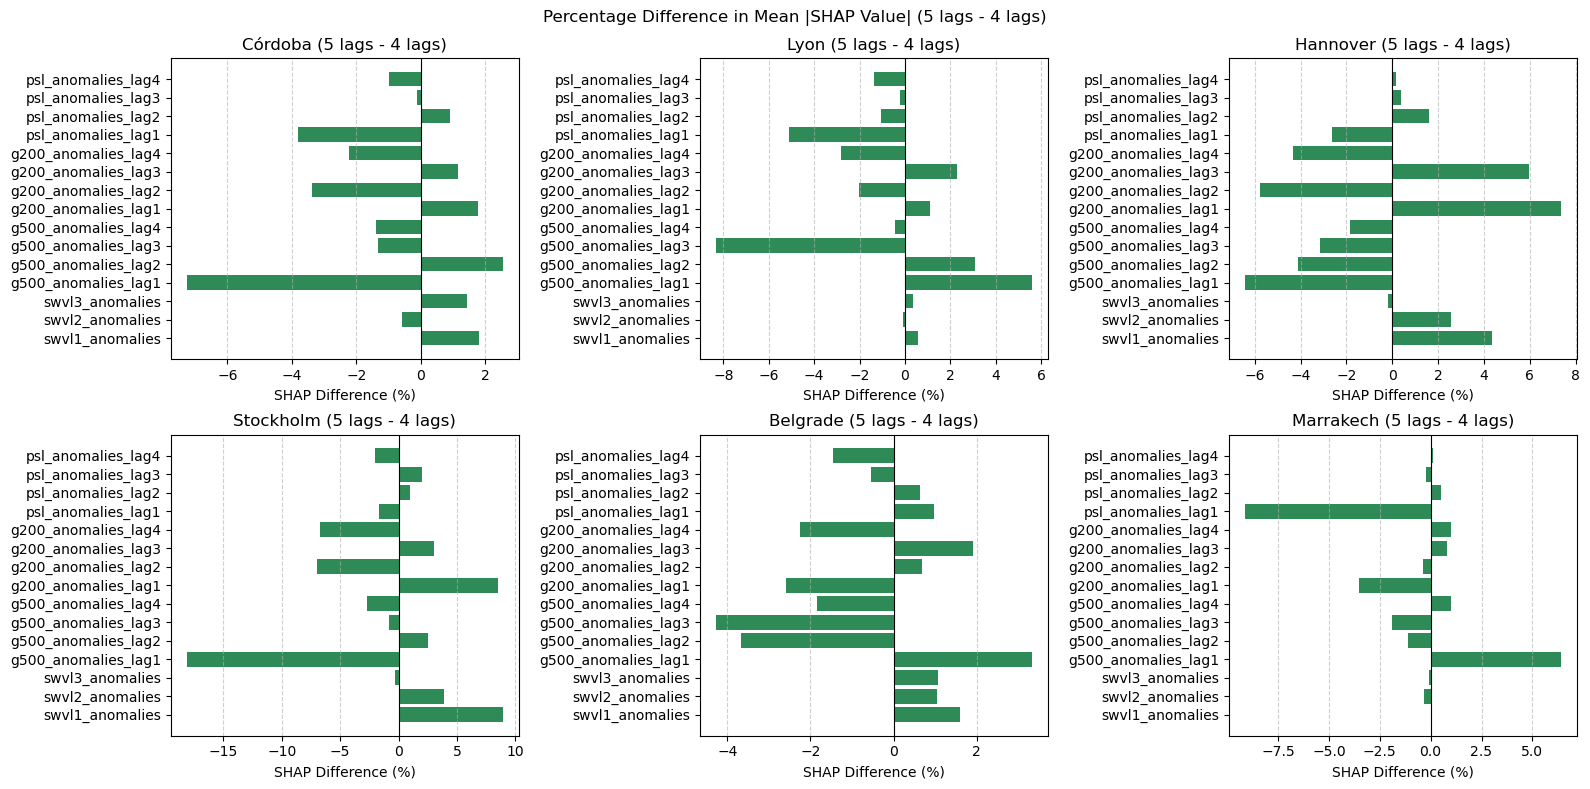

In [42]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

number_lags=5
train_features_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, start_date='1950-01-03', end_date='2013-12-31',months=[6,7,8],lags_era5=number_lags+1) # shape: features, time, lat, lon 


sites = ['cordoba','lyon','hannover','stockholm','belgrado','marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, site in enumerate(sites):
    print(f"Processing site: {site}")

    train_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_98p_extreme_detection.nc", start_date="1950-01-03", end_date="2013-12-31", months=[6,7,8])
    combined_train_dataset  = functions_NN_extremes.CombinedDataset(train_dataset,train_features_era5)

    
    # Load both SHAP result files
    with open(f'SHAP_values_Gradient/shap_values_GradientExplainer_not_filtered_{site}_test_4lags.pkl', 'rb') as f:
        shap_2lags = pickle.load(f)
    with open(f'SHAP_values_Gradient/shap_values_GradientExplainer_not_filtered_{site}_test_5lags.pkl', 'rb') as f:
        shap_3lags = pickle.load(f)

    # Extract and filter SHAP values
    def filter_shap(raw, y_true, y_pred, out_probs):
        mask = np.zeros_like(out_probs, dtype=bool)
        for j in range(out_probs.shape[1]):
            threshold = np.percentile(out_probs[:, j], 100 - 25)
            mask[:, j] = out_probs[:, j] >= threshold
        mask_def = mask[:, 0] | mask[:, 1]
        mask_def_extreme = mask_def & (y_pred == 1)
        shap_nn = raw['nn'][mask_def_extreme]
        shap_cnn = raw['cnn'][mask_def_extreme]
        shap_cnn = np.sum(shap_cnn, axis=(2, 3))  # spatial sum
        return np.concatenate([shap_nn, shap_cnn], axis=1)

    shap_val_2 = filter_shap(shap_2lags, np.array(shap_2lags['y_true']), np.array(shap_2lags['y_pred']), shap_2lags['out_probs'])
    shap_val_3 = filter_shap(shap_3lags, np.array(shap_3lags['y_true']), np.array(shap_3lags['y_pred']), shap_3lags['out_probs'])

    # Compute mean absolute SHAPs
    mean_abs_2 = np.mean(np.abs(shap_val_2), axis=0)
    sum_mean_abs_2 = np.sum(mean_abs_2,axis=0)
    mean_abs_2 = mean_abs_2 / sum_mean_abs_2 *100
    
    mean_abs_3 = np.mean(np.abs(shap_val_3), axis=0)
    sum_mean_abs_3 = np.sum(mean_abs_3,axis=0)
    mean_abs_3 = mean_abs_3 / sum_mean_abs_3 *100
    
    nn_feature_names = train_dataset.all_features
    cnn_feature_names = train_features_era5.all_features
    all_names = nn_feature_names + cnn_feature_names
    
    # Clean names (same logic as before)
    cleaned_names = [
        name.replace(" anomalies", "").replace("lagged_era5", "") if "lagged_era5" in name else name.replace(" anomalies", "")
        for name in all_names
    ]
    
    # Detect lag 3 features (based on naming convention)
    lag3_mask = np.array(['lag5' in name for name in all_names])
    
    # Filter out lag-3 values
    mean_abs_3_filtered = mean_abs_3[~lag3_mask]
    cleaned_names_filtered = np.array(cleaned_names)[~lag3_mask]
    

    # Compute difference (3 lags - 2 lags)
    shap_diff = mean_abs_3_filtered - mean_abs_2 

   
    # Plot
    ax = axes[i]
    ax.barh(cleaned_names_filtered, shap_diff, color='seagreen')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"{sites_title[i]} (5 lags - 4 lags)")
    ax.set_xlabel("SHAP Difference (%)")
    ax.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.suptitle("Percentage Difference in Mean |SHAP Value| (5 lags - 4 lags)")
plt.subplots_adjust(top=0.92)
plt.savefig("/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/SHAP_values_Gradient/SHAP_diff_5lags_minus_4lags.pdf")
plt.show()


## Beeswarm SHAP plot using Matplotlib

doing site: cordoba
doing site: lyon
doing site: hannover
doing site: stockholm
doing site: belgrado


/scratch/tmp/23481838/ipykernel_390718/873686652.py:216: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(right=0.85)


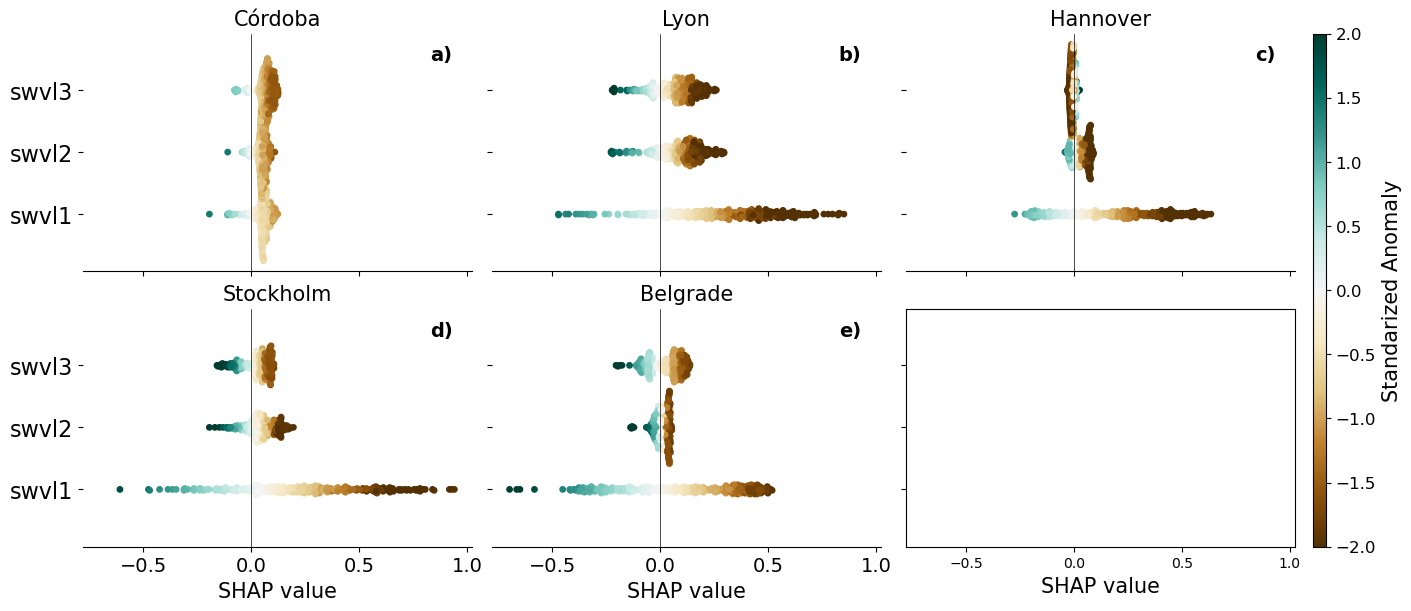

In [7]:
import matplotlib.pyplot as plt
import shap
import pickle
import numpy as np
from io import BytesIO
from PIL import Image
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import rankdata

import shap
shap_colors = shap.plots.colors.red_blue

shap_color_func = shap.plots.colors.red_blue  # this is a function
color_vals = np.linspace(0, 1, 256)           # 256 gradient steps
rgb_colors = [shap_color_func(v) for v in color_vals]  # sample into RGB

shap_colormap = LinearSegmentedColormap.from_list(
    "shap_red_blue", 
    rgb_colors
)

soil_moisture_colors = LinearSegmentedColormap.from_list(
    "soil_moisture_brown_green",
    ["saddlebrown", "wheat", "yellowgreen", "forestgreen"],
    N=256
)

def beeswarm_y(vals, gap=0.01):
    """
    Generates SHAP-like vertical jittering to separate overlapping SHAP values.
    Now with centered bidirectional offsets (up/down) to avoid stacking only above.
    """
    from collections import defaultdict

    sorted_idx = np.argsort(vals)
    sorted_vals = vals[sorted_idx]

    y_positions = np.zeros(len(vals))
    layers = defaultdict(list)

    for idx, val in zip(sorted_idx, sorted_vals):
        for layer_num in range(100):  
            offset = (layer_num + 1) // 2 * (-1)**layer_num 
            layer = layers[offset]
            if all(abs(val - v) > gap for v in layer):
                layer.append(val)
                y_positions[idx] = offset
                break

    # Scale spacing for aesthetics
    y_positions = y_positions * 0.15
    return y_positions

def custom_summary_plot(ax, shap_values, features, feature_names, cmap=cm.coolwarm, dot_size=15,vmin=-2,vmax=2):
    num_features = shap_values.shape[1]

    for i in range(num_features):
        vals = shap_values[:, i]
        color_vals = features[:, i]
        y_offsets = beeswarm_y(vals) * 0.1  # scale for vertical spread

        ax.scatter(vals, i + y_offsets,
                   c=color_vals, cmap=cmap,
                   s=dot_size, alpha=1, edgecolors=None, vmin=-2, vmax=2)

    ax.set_yticks(range(num_features))
    ax.set_yticklabels(feature_names, fontsize=16)
    ax.tick_params(axis='x', labelsize=14)



fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True,constrained_layout=True) # sharex and sharey
axs = axs.flatten()

sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

sites = ['cordoba','lyon','hannover' ,'stockholm', 'belgrado']

v_min = 0 
v_max = 0

for count_plot, site in enumerate(sites):

    print(f"doing site: {site}")

    #train_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_extreme_detection.nc", start_date="1950-01-03", end_date="2013-12-31", months=[6,7,8])
    #test_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_extreme_detection.nc", start_date="2014-01-01", end_date="2024-12-31", months=[6,7,
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"

    start_date = "1950-01-01"
    
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"
    _ERA5LAND_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2023-12-31",
    months = [6,7,8]         
        )

    _ERA5_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2023-12-31",
    start_lag = 1,
    lags_era5 = 3,
    months = [6,7,8],
            )

    train_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/obs_lagged_anomalies_and_event_detection/obs_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 ,start_date=start_date, end_date="2013-12-31", months=[6,7,8])
    test_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/obs_lagged_anomalies_and_event_detection/obs_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 ,start_date="2014-01-01", end_date="2023-12-31", months=[6,7,8])
        

    train_features_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, start_date=start_date, end_date='2013-12-31',months=[6,7,8],start_lag=1,lags_era5=number_lags) # shape: features, time, lat, lon 
    test_features_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, start_date='2014-01-01', end_date='2023-12-31', months=[6,7,8],start_lag=1,lags_era5=number_lags)


    combined_train_dataset  = functions_NN_extremes.CombinedDataset(train_dataset,train_features_era5)
    combined_test_dataset = functions_NN_extremes.CombinedDataset(test_dataset,test_features_era5)

    #complete_era5land = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , **_ERA5LAND_COMPLETE_DATASET_CONF)
    #complete_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_COMPLETE_DATASET_CONF)
    #complete_combined_dataset = functions_NN_extremes.CombinedDataset(complete_era5land,complete_era5)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Explainer data for SHAP 
    
    explainer_indices = np.arange(0,len(combined_test_dataset),1)
    
    explain_nn = []
    explain_cnn = []
    
    for idx in explainer_indices:
        nn_input, cnn_input, labels = combined_test_dataset[idx] # Adjust based on your dataset structure
        explain_nn.append(nn_input)
        explain_cnn.append(cnn_input)
    
    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    explain_cnn = torch.stack(explain_cnn,dim=0).to(device)
    
    explain_data = [explain_nn, explain_cnn]
    
    #with open(f'SHAP_values_Gradient/def_ensamble/95p_SHAP_results_{site}.pkl', 'rb') as f:
    with open(f'/gpfs/projects/bsc32/bsc167965/SHAP_values_Gradient/def_ensamble/obs_TX_SHAP_results_{site}.pkl', 'rb') as f:
        loaded_shap_dict = pickle.load(f)
    main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
    with open(os.path.join(main_path, f'obs_TX_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)
    out_probabilities = dict_results['out_probs_sites']
    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = np.zeros_like(out_probabilities, dtype=bool)
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 0.75)
        mask[:, i] = out_probabilities[:, i] >= threshold
    mask_def = mask[:, 0] | mask[:, 1]
    mask_def_extreme = mask_def & (y_pred == 1)
    shap_values_nn_raw = loaded_shap_dict['nn_mean']
    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    input_data = explain_nn.cpu().numpy()[mask_def_extreme]
    nn_feature_names = train_dataset.all_features

    cleaned_names = [
        name.replace("_anomalies", "").replace("lagged_era5", "")
        if "lagged_era5" in name else name.replace("_anomalies", "")
        for name in nn_feature_names ]
    
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered[:,1:4],
        data=input_data[:,1:4],
        feature_names=cleaned_names[1:4])
    
  
    
    ax = axs[count_plot]
    custom_summary_plot(ax, shap_values_nn_filtered[:,1:4], input_data[:,1:4], cleaned_names[1:4],cmap="BrBG", vmin=-2, vmax=2)
    ax.set_title(sites_title[count_plot], fontsize=15)
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='-')
    ax.text(0.95, 0.95, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=ax.transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')
    #ax.tick_params(axis='both', which='major', labelsize=18) # Change tick font s
    #ax.set_ylabel()

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    v_min_temp = np.min(input_data[:,1:4])
    v_max_temp = np.max(input_data[:,1:4])

    if v_min_temp < v_min:
        v_min = v_min_temp
    elif v_max_temp > v_max: 
        v_max = v_max_temp

from mpl_toolkits.axes_grid1 import make_axes_locatable

for i in range(3,6):
    axs[i].set_xlabel("SHAP value", fontsize=15)

norm = plt.Normalize(vmin=-2, vmax=2)
sm = plt.cm.ScalarMappable(cmap='BrBG', norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.01, label='Anomaly', aspect=40)
cbar.set_label(r'Standarized Anomaly', fontsize=15)

cbar.ax.tick_params(labelsize=12)

#plt.tight_layout(rect=[0, 0, 1, 0.9], h_pad=3, w_pad=2)
#plt.suptitle("SHAP values swvl across samples CombinedModel",fontsize=15)
plt.subplots_adjust(right=0.85)
#fig.savefig("../input_data/arnau-tfm/plots/SHAP_values_Gradient/belgrado_std_change_beeswarm_swvl_shap_locations.pdf")
plt.show()

## Beeswarm plot FullPeriod

doing site: cordoba
doing site: lyon
doing site: hannover
doing site: stockholm
doing site: belgrado
doing site: marrakech


/scratch/tmp/22710743/ipykernel_1453284/3745212004.py:207: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(right=0.85)


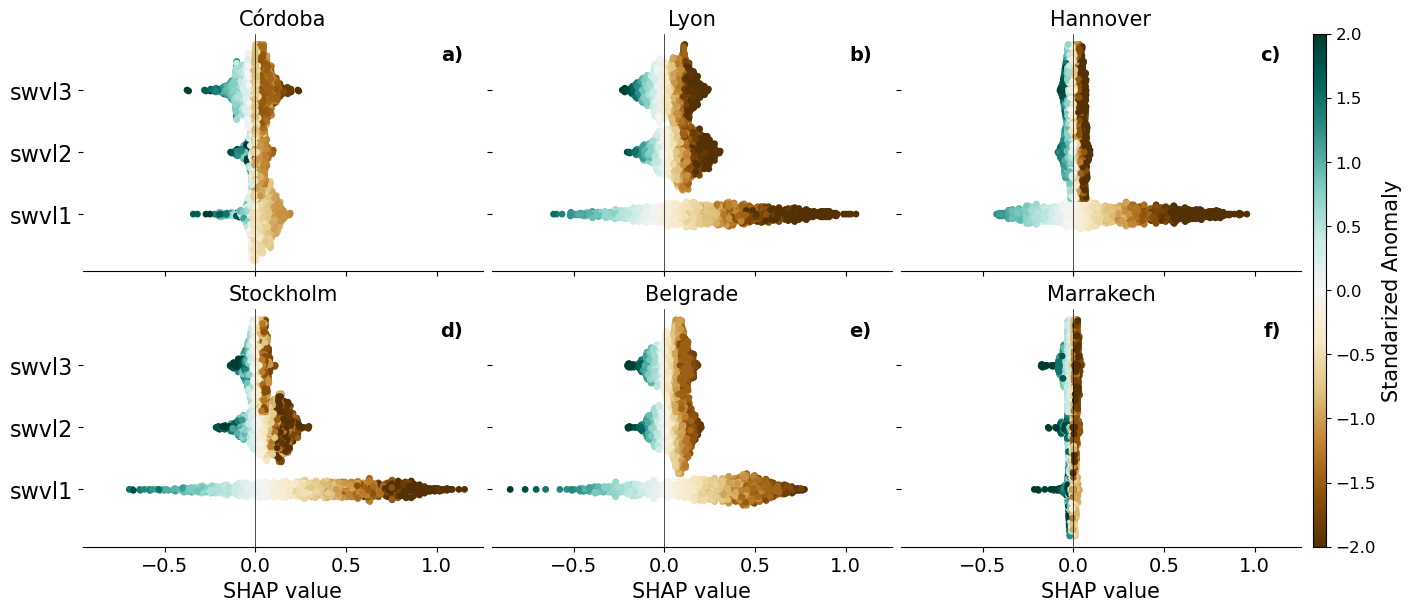

In [8]:
import matplotlib.pyplot as plt
import shap
import pickle
import numpy as np
from io import BytesIO
from PIL import Image
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import rankdata

import shap
shap_colors = shap.plots.colors.red_blue

shap_color_func = shap.plots.colors.red_blue  # this is a function
color_vals = np.linspace(0, 1, 256)           # 256 gradient steps
rgb_colors = [shap_color_func(v) for v in color_vals]  # sample into RGB

shap_colormap = LinearSegmentedColormap.from_list(
    "shap_red_blue", 
    rgb_colors
)

soil_moisture_colors = LinearSegmentedColormap.from_list(
    "soil_moisture_brown_green",
    ["saddlebrown", "wheat", "yellowgreen", "forestgreen"],
    N=256
)

def beeswarm_y(vals, gap=0.01):
    """
    Generates SHAP-like vertical jittering to separate overlapping SHAP values.
    Now with centered bidirectional offsets (up/down) to avoid stacking only above.
    """
    from collections import defaultdict

    sorted_idx = np.argsort(vals)
    sorted_vals = vals[sorted_idx]

    y_positions = np.zeros(len(vals))
    layers = defaultdict(list)

    for idx, val in zip(sorted_idx, sorted_vals):
        # Try placing in layers: 0, +1, -1, +2, -2, ...
        for layer_num in range(100):  # Prevent infinite loop
            offset = (layer_num + 1) // 2 * (-1)**layer_num  # 0, 1, -1, 2, -2, ...
            layer = layers[offset]
            if all(abs(val - v) > gap for v in layer):
                layer.append(val)
                y_positions[idx] = offset
                break

    # Scale spacing for aesthetics
    y_positions = y_positions * 0.15
    return y_positions

def custom_summary_plot(ax, shap_values, features, feature_names, cmap=cm.coolwarm, dot_size=15,vmin=-2,vmax=2):
    num_features = shap_values.shape[1]

    for i in range(num_features):
        vals = shap_values[:, i]
        color_vals = features[:, i]
        y_offsets = beeswarm_y(vals) * 0.1  # scale for vertical spread

        ax.scatter(vals, i + y_offsets,
                   c=color_vals, cmap=cmap,
                   s=dot_size, alpha=1, edgecolors=None, vmin=-2, vmax=2)

    ax.set_yticks(range(num_features))
    ax.set_yticklabels(feature_names, fontsize=16)
    ax.tick_params(axis='x', labelsize=14)



fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True,constrained_layout=True) # sharex and sharey
axs = axs.flatten()

sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

sites = ['cordoba','lyon','hannover' ,'stockholm', 'belgrado', 'marrakech']

v_min = 0 
v_max = 0

for count_plot, site in enumerate(sites):

    print(f"doing site: {site}")

    #train_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_extreme_detection.nc", start_date="1950-01-03", end_date="2013-12-31", months=[6,7,8])
    #test_dataset = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_extreme_detection.nc", start_date="2014-01-01", end_date="2024-12-31", months=[6,7,
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"
    if site == 'belgrado': # Special case Belgrado to capture correctly the trend, discarding special case 1950 and 1952, which have a high extreme count. 
            start_date = "1953-01-01"
    else:
        start_date = "1950-01-01"
    
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"
    _ERA5LAND_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2024-12-31",
    months = [6,7,8]         
        )

    _ERA5_COMPLETE_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2024-12-31",
    start_lag = 1,
    lags_era5 = 3,
    months = [6,7,8],
            )

    complete_era5land = functions_NN_extremes.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/std_changed_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 , **_ERA5LAND_COMPLETE_DATASET_CONF)
    complete_era5 = functions_NN_extremes.ERA5Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_COMPLETE_DATASET_CONF)
    complete_combined_dataset = functions_NN_extremes.CombinedDataset(complete_era5land,complete_era5)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Explainer data for SHAP 
    
    explainer_indices = np.arange(0,len(complete_combined_dataset),1)
    
    explain_nn = []
    explain_cnn = []
    
    for idx in explainer_indices:
        nn_input, cnn_input, labels = complete_combined_dataset[idx] # Adjust based on your dataset structure
        explain_nn.append(nn_input)
        explain_cnn.append(cnn_input)
    
    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    explain_cnn = torch.stack(explain_cnn,dim=0).to(device)
    
    explain_data = [explain_nn, explain_cnn]
    
    #with open(f'SHAP_values_Gradient/def_ensamble/95p_SHAP_results_{site}.pkl', 'rb') as f:
    with open(f'/gpfs/projects/bsc32/bsc167965/SHAP_values_Gradient/def_ensamble/FullPeriod_SHAP_results_{site}.pkl', 'rb') as f:
        loaded_shap_dict = pickle.load(f)
    main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
    with open(os.path.join(main_path, f'FullPeriod_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)
    out_probabilities = dict_results['out_probs_sites']
    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = np.zeros_like(out_probabilities, dtype=bool)
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 0.75)
        mask[:, i] = out_probabilities[:, i] >= threshold
    mask_def = mask[:, 0] | mask[:, 1]
    mask_def_extreme = mask_def & (y_pred == 1)
    shap_values_nn_raw = loaded_shap_dict['nn_mean']
    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    input_data = explain_nn.cpu().numpy()[mask_def_extreme]
    nn_feature_names = train_dataset.all_features

    cleaned_names = [
        name.replace("_anomalies", "").replace("lagged_era5", "")
        if "lagged_era5" in name else name.replace("_anomalies", "")
        for name in nn_feature_names ]
    
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered[:,1:4],
        data=input_data[:,1:4],
        feature_names=cleaned_names[1:4])
    
  
    
    ax = axs[count_plot]
    custom_summary_plot(ax, shap_values_nn_filtered[:,1:4], input_data[:,1:4], cleaned_names[1:4],cmap="BrBG", vmin=-2, vmax=2)
    ax.set_title(sites_title[count_plot], fontsize=15)
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='-')
    ax.text(0.95, 0.95, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=ax.transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')
    #ax.tick_params(axis='both', which='major', labelsize=18) # Change tick font s
    #ax.set_ylabel()

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    v_min_temp = np.mean(input_data[:,1:4])
    v_max_temp = np.max(input_data[:,1:4])

    if v_min_temp < v_min:
        v_min = v_min_temp
    elif v_max_temp > v_max: 
        v_max = v_max_temp

from mpl_toolkits.axes_grid1 import make_axes_locatable

for i in range(3,6):
    axs[i].set_xlabel("SHAP value", fontsize=15)

norm = plt.Normalize(vmin=-2, vmax=2)
sm = plt.cm.ScalarMappable(cmap='BrBG', norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.01, label='Anomaly', aspect=40)
cbar.set_label(r'Standarized Anomaly', fontsize=15)

cbar.ax.tick_params(labelsize=12)

#plt.tight_layout(rect=[0, 0, 1, 0.9], h_pad=3, w_pad=2)
#plt.suptitle("SHAP values swvl across samples CombinedModel",fontsize=15)
plt.subplots_adjust(right=0.85)
fig.savefig("../input_data/arnau-tfm/plots/SHAP_values_Gradient/FullPeriod_beeswarm_swvl_shap_locations.pdf")
plt.show()

# EOF SHAP values

KeyError: 'nn_mean'

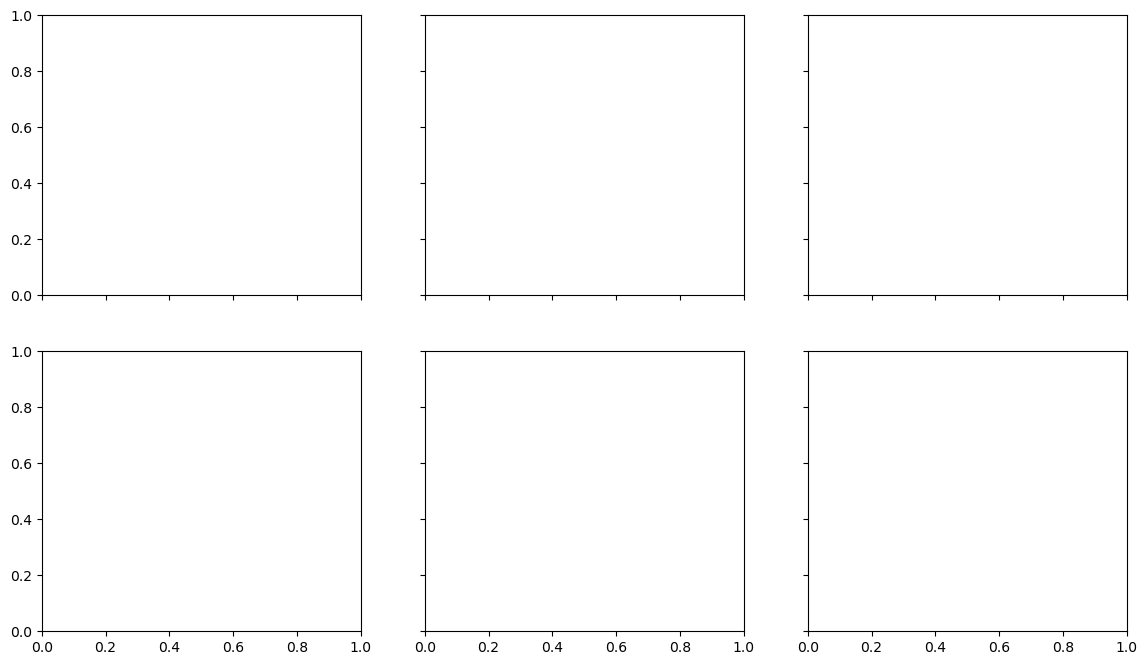

In [3]:

seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available(): # Only seed cuda if available
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU.
np.random.seed(seed)  # Numpy module.
random.seed(seed)  # Python random module.
torch.manual_seed(seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False

g = torch.Generator()
g.manual_seed(seed)

def draw_colored_text_block(ax, x, y, items):
    for i, (name, value, color) in enumerate(items):
        ax.text(x, y - i*0.07, f"{name}: {value:.1f}%", transform=ax.transAxes,
                fontsize=11, color=color, verticalalignment='top')


atmo_color = 'steelblue' 
land_color = 'saddlebrown'    
co2_color = 'dimgray'  

file_g500 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/eofs/g500_pcs.nc"
file_g200 = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/eofs/g200_pcs.nc"
file_psl = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/eofs/psl_pcs.nc"

sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

_DATALOADERS_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = True,
        num_workers=0,
        generator=g        # make shuffle deterministic 
    )

_DATALOADERS_TEST_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = False,
        num_workers=0
    )


def verify_determinism():
    # Check PyTorch
    print(f"PyTorch rand(): {torch.rand(1).item()}")  # Should match across runs
    
    # Check NumPy
    print(f"NumPy rand(): {np.random.rand()}")  # Should match
    
    # Check Python random
    print(f"Python random(): {random.random()}")  # Should match


def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    g.manual_seed(seed)  # For DataLoader's generator


fig_bar,axes_bar = plt.subplots(2,3,figsize=(14,8), sharex='col', sharey='row')
axes_bar = axes_bar.flatten()

sites = ['cordoba']

sites = ['cordoba','lyon','hannover','stockholm','belgrado','marrakech']


count_plot = 0
for m,site in enumerate(sites): 

    reset_seeds(seed)

    file_path_loc = f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_extreme_detection.nc"
    
    
    
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"
    
    train_dataset = functions_NN_extremes.ERA5LandDataset_extremes_eofs_swvl_average_CO2(file_path_loc,file_CO2,file_g500,file_g200,file_psl, start_date='1950-01-03', end_date='2013-12-31',months=[6,7,8],lags_eof=4)
    

    test_dataset = functions_NN_extremes.ERA5LandDataset_extremes_eofs_swvl_average_CO2(file_path_loc,file_CO2,file_g500,file_g200,file_psl, start_date='2014-01-01', end_date='2024-12-31', months=[6,7,8],lags_eof=4)
    train_size = int(0.8 * len(train_dataset))  # 80% for training
    val_size = len(train_dataset) - train_size  # 20% for validation
    
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    main_path = "/home/bsc/bsc167965/TFM/ML/SHAP_gradient_EOF/"
    with open(os.path.join(main_path, f'CO2_shap_values_EOFsNN_not_filtered_{site}_test_3lags.pkl'), 'rb') as f:
        shap_results = pickle.load(f)

    main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
    
    with open(os.path.join(main_path, f'EOFs_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)
    

    out_probabilities = dict_results['out_probs_sites']   

    y_true, y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
        
    # Filter the predictions based on probabilities 
        
        
    mask = np.zeros_like(out_probabilities, dtype=bool)
    
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 100 - 25)
    
        mask[:, i] = out_probabilities[:, i] >= threshold
    
    mask_def = mask[:,0] | mask[:,1] #True if either class 0 or 1 correspond to the top % confidence 

    mask_def_extreme = mask_def & (y_pred == 1)

    # Load SHAP values 

    shap_values_nn_raw = shap_results['nn_mean']

    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    
    all_names = train_dataset.all_features
    
    cleaned_names = [
    name.replace("_anomalies", "").replace("lagged_era5", "")
    if "lagged_era5" in name else name.replace("_anomalies", "")
    for name in all_names
    ]


    # Assign colors per feature group
    color_mapping = {}
    circulation_features = ['g500', 'g200', 'psl']
    land_features = ['swvl1', 'swvl2', 'swvl3']
    co2_feature = ['co2']  # assuming the CO2 feature is named "co2"
    
    for name in cleaned_names:
        lname = name.lower()
        if any(circ in lname for circ in circulation_features):
            color_mapping[name] = atmo_color
        elif any(swvl in lname for swvl in land_features):
            name = name.replace("_anomalies", "")
            color_mapping[name] = land_color
        elif 'co2' in lname:
            color_mapping[name] = co2_color

    shap_df = pd.DataFrame(shap_values_nn_filtered, columns=all_names)

    # Take absolute values
    abs_shap_df = shap_df.abs()
    
    # Initialize a dictionary to store grouped SHAP values
    grouped_shap = {}
    
    # Handle swvl1, swvl2, swvl3 individually
    for var in ['co2','swvl1_anomalies', 'swvl2_anomalies', 'swvl3_anomalies']:
        grouped_shap[var] = abs_shap_df[var].mean()
    
    # Define variables and lags
    circulation_vars = ['g500', 'g200', 'psl']
    lags = ['lag1', 'lag2', 'lag3']
    
    # Group and sum EOFs per variable per lag
    for var in circulation_vars:
        for lag in lags:
            # Build feature name prefix
            prefix = f"pcs_{var}_{lag}_"
            # Select columns matching this prefix
            matching_cols = [col for col in abs_shap_df.columns if col.startswith(prefix)]
            # Mean absolute SHAP value across all EOFs for this variable-lag combo
            grouped_shap[f"{var}_{lag}"] = abs_shap_df[matching_cols].sum(axis=1).mean()
    
    # Convert to a DataFrame for easier display
    summary_df = pd.DataFrame.from_dict(grouped_shap, orient='index', columns=['mean_abs_shap'])

    total_SHAP = np.sum(summary_df["mean_abs_shap"] )
    atmosphere_SHAP = np.sum(summary_df["mean_abs_shap"][4:])  / total_SHAP * 100
    land_SHAP = np.sum(summary_df["mean_abs_shap"][1:4]) / total_SHAP * 100
    co2_SHAP = np.sum(summary_df["mean_abs_shap"][:1]) / total_SHAP * 100
    
    axes_bar[count_plot].set_xlim(0,50)
    bar_colors = [
        color_mapping[name.replace("_anomalies", "")] if 'swvl' in name else color_mapping[name]
        for name in cleaned_names
    ]
    plot_labels = [label.replace("_anomalies", "") if "swvl" in label else label for label in summary_df.index]
    axes_bar[count_plot].barh(plot_labels,summary_df["mean_abs_shap"] / total_SHAP * 100 , color=bar_colors)
    axes_bar[count_plot].set_title(f"{sites_title[m]}",fontsize=15)
    axes_bar[count_plot].text(0.95, 0.75, f'{chr(97+count_plot)})',  # 97 is ASCII for 'a'
                            transform=axes_bar[count_plot].transAxes,
                            fontsize=14,
                            fontweight='bold',
                            va='top',
                            ha='right')

    summary_items = [
        ("Land SHAP", land_SHAP, 'saddlebrown'),
        ("Atmo. SHAP", atmosphere_SHAP, 'darkblue'),
        ("CO₂ SHAP", co2_SHAP, 'black')
    ]
    draw_colored_text_block(axes_bar[count_plot], 0.6, 0.95, summary_items)

    axes_bar[count_plot].tick_params(axis='x', labelsize=12)  
    axes_bar[count_plot].tick_params(axis='y', labelsize=12) 
    axes_bar[count_plot].tick_params(axis='y', labelsize=14) 
    
    count_plot += 1

for m in range(3,6):
    axes_bar[m].set_xlabel("Percentage(%)",fontsize=15)

fig_bar.tight_layout()
number_lags=3
#fig_bar.savefig(f"/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/SHAP_values_Gradient/EOFsNN_SHAP_plot_CO2_all_locations_{number_lags}lags.pdf")
        


doing site: cordoba
doing site: lyon
doing site: hannover
doing site: stockholm
doing site: belgrado
doing site: marrakech


/scratch/tmp/21374652/ipykernel_2511054/586525253.py:186: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(right=0.85)


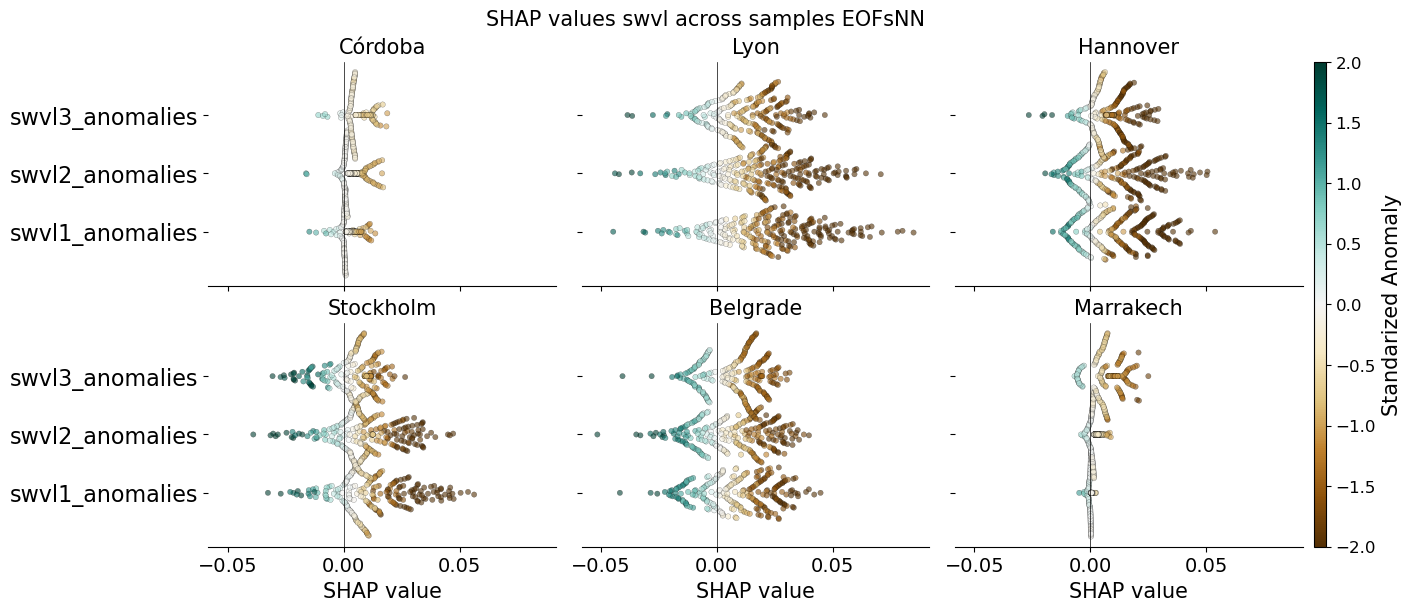

In [22]:
import matplotlib.pyplot as plt
import shap
import pickle
import numpy as np
from io import BytesIO
from PIL import Image
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import rankdata

import shap
shap_colors = shap.plots.colors.red_blue

shap_color_func = shap.plots.colors.red_blue  # this is a function
color_vals = np.linspace(0, 1, 256)           # 256 gradient steps
rgb_colors = [shap_color_func(v) for v in color_vals]  # sample into RGB

shap_colormap = LinearSegmentedColormap.from_list(
    "shap_red_blue", 
    rgb_colors
)

soil_moisture_colors = LinearSegmentedColormap.from_list(
    "soil_moisture_brown_green",
    ["saddlebrown", "wheat", "yellowgreen", "forestgreen"],
    N=256
)

def beeswarm_y(vals, gap=0.01):
    """
    Generates SHAP-like vertical jittering to separate overlapping SHAP values.
    Now with centered bidirectional offsets (up/down) to avoid stacking only above.
    """
    from collections import defaultdict

    sorted_idx = np.argsort(vals)
    sorted_vals = vals[sorted_idx]

    y_positions = np.zeros(len(vals))
    layers = defaultdict(list)

    for idx, val in zip(sorted_idx, sorted_vals):
        # Try placing in layers: 0, +1, -1, +2, -2, ...
        for layer_num in range(100):  # Prevent infinite loop
            offset = (layer_num + 1) // 2 * (-1)**layer_num  # 0, 1, -1, 2, -2, ...
            layer = layers[offset]
            if all(abs(val - v) > gap for v in layer):
                layer.append(val)
                y_positions[idx] = offset
                break

    # Scale spacing for aesthetics
    y_positions = y_positions * 0.15
    return y_positions

def custom_summary_plot(ax, shap_values, features, feature_names, cmap=cm.coolwarm, dot_size=15,vmin=-2,vmax=2):
    num_features = shap_values.shape[1]

    for i in range(num_features):
        vals = shap_values[:, i]
        color_vals = features[:, i]
        y_offsets = beeswarm_y(vals) * 0.1  # scale for vertical spread

        ax.scatter(vals, i + y_offsets,
                   c=color_vals, cmap=cmap,
                   s=dot_size, alpha=0.6, edgecolors='k', linewidth=0.2, vmin=-2, vmax=2)

    ax.set_yticks(range(num_features))
    ax.set_yticklabels(feature_names, fontsize=16)
    ax.tick_params(axis='x', labelsize=14)



fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True,constrained_layout=True) # sharex and sharey
axs = axs.flatten()

sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

sites = ['cordoba','lyon','hannover','stockholm','belgrado','marrakech']

v_min = 0 
v_max = 0

for count_plot, site in enumerate(sites):

    print(f"doing site: {site}")

    file_path_loc = f"/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/{site}_lagged_standarized_anomalies_and_extreme_detection.nc"
     
    file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"
    
    train_dataset = functions_NN_extremes.ERA5LandDataset_extremes_eofs_swvl_average_CO2(file_path_loc,file_CO2,file_g500,file_g200,file_psl, start_date='1950-01-03', end_date='2013-12-31',months=[6,7,8],lags_eof=4)
    

    test_dataset = functions_NN_extremes.ERA5LandDataset_extremes_eofs_swvl_average_CO2(file_path_loc,file_CO2,file_g500,file_g200,file_psl, start_date='2014-01-01', end_date='2024-12-31', months=[6,7,8],lags_eof=4)
    train_size = int(0.8 * len(train_dataset))  # 80% for training
    val_size = len(train_dataset) - train_size  # 20% for validation
    
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    explainer_indices = np.arange(0,len(test_dataset),1)
    
    explain_nn = []
    
    for idx in explainer_indices:
        nn_input, labels = test_dataset[idx] # Adjust based on your dataset structure
        explain_nn.append(nn_input)
    
    explain_nn = torch.stack(explain_nn,dim=0).to(device)
    

    
    main_path = "/home/bsc/bsc167965/TFM/ML/SHAP_values_Gradient/"
    with open(os.path.join(main_path, f'EOFs_SHAP_results_{site}.pkl'), 'rb') as f:
        shap_results = pickle.load(f)

    main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'
    
    with open(os.path.join(main_path, f'EOFs_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)
        
    out_probabilities = dict_results['out_probs_sites']
    y_true,y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = np.zeros_like(out_probabilities, dtype=bool)
    for i in range(out_probabilities.shape[1]):
        threshold = np.percentile(out_probabilities[:, i], 75)
        mask[:, i] = out_probabilities[:, i] >= threshold
    mask_def = mask[:, 0] | mask[:, 1]
    mask_def_extreme = mask_def & (y_pred == 1)
    shap_values_nn_raw = shap_results['nn_mean']
    shap_values_nn_filtered = shap_values_nn_raw[mask_def_extreme]
    input_data = explain_nn.cpu().numpy()[mask_def_extreme]
    nn_feature_names = train_dataset.all_features

    cleaned_names = [
        name.replace(" anomalies", "").replace("lagged_era5", "")
        if "lagged_era5" in name else name.replace(" anomalies", "")
        for name in nn_feature_names ]
    
    expl_nn = shap.Explanation(
        values=shap_values_nn_filtered[:,1:4],
        data=input_data[:,1:4],
        feature_names=cleaned_names[1:4])
    
  
    
    ax = axs[count_plot]
    custom_summary_plot(ax, shap_values_nn_filtered[:,1:4], input_data[:,1:4], cleaned_names[1:4],cmap="BrBG", vmin=-2, vmax=2)
    ax.set_title(sites_title[count_plot], fontsize=15)
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='-')
    #ax.tick_params(axis='both', which='major', labelsize=18) # Change tick font s
    #ax.set_ylabel()

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    v_min_temp = np.mean(input_data[:,1:4])
    v_max_temp = np.max(input_data[:,1:4])

    if v_min_temp < v_min:
        v_min = v_min_temp
    elif v_max_temp > v_max: 
        v_max = v_max_temp

from mpl_toolkits.axes_grid1 import make_axes_locatable

for i in range(3,6):
    axs[i].set_xlabel("SHAP value", fontsize=15)

norm = plt.Normalize(vmin=-2, vmax=2)
sm = plt.cm.ScalarMappable(cmap='BrBG', norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.01, label='Anomaly', aspect=40)
cbar.set_label(r'Standarized Anomaly', fontsize=15)

cbar.ax.tick_params(labelsize=12)

#plt.tight_layout(rect=[0, 0, 1, 0.9], h_pad=3, w_pad=2)
plt.suptitle("SHAP values swvl across samples EOFsNN",fontsize=15)
plt.subplots_adjust(right=0.85)
fig.savefig("../input_data/arnau-tfm/plots/SHAP_values_Gradient/EOFsNN_beeswarm_swvl_shap_locations.pdf")
plt.show()